Load different models for the purpose of evaluation

In [14]:
import torch
import torch.nn as nn
import kan
from kan import KAN
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device("mps")

In [5]:
PIKAN = KAN(width=[2, 20, 20, 1], grid=5, k=3).to(device)

checkpoint directory created: ./model
saving model version 0.0


In [6]:
PIKAN.load_state_dict(torch.load('Models/trained_kan_weights_2026-04-09'))

<All keys matched successfully>

In [17]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)
    
model_pinn = PINN()
model_uninformed = PINN()
model_pinn.to(device)
model_uninformed.to(device)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=1, bias=True)
  )
)

In [18]:
model_pinn.load_state_dict(torch.load('Models/pinn_model_weights_run_2026-03-13'))
model_uninformed.load_state_dict(torch.load('Models/standard_model_weights_run_2026-03-13'))

<All keys matched successfully>

In [61]:
def evaluate_models(model_pinn, model_uninformed, pi_kan, x_true, u_true, test_grid_size, t_eval=0.9):
    
    # Ensure models are in evaluation mode to disable dropout/batchnorm artifacts
    model_pinn.eval()
    model_uninformed.eval()
    
    # Establish computational device and generate continuous coordinate grid
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    test_x_vis = torch.linspace(-1, 1, test_grid_size).view(-1, 1).to(device)
    test_t_vis = torch.full((test_grid_size, 1), t_eval).to(device)

    kan_input = torch.cat([test_x_vis, test_t_vis], dim=1)
    
    # Query the neural function approximators
    with torch.no_grad():
        pred_pinn = model_pinn(test_x_vis, test_t_vis).cpu().numpy()
        pred_uninformed = model_uninformed(test_x_vis, test_t_vis).cpu().numpy()
        pred_pikan = pi_kan(kan_input).cpu().numpy()

    # Visualization Architecture
    fig, axs = plt.subplots(1, 4, figsize=(24, 5), sharey=True, sharex=True)
    fig.suptitle(f"Extrapolation Analysis at t={t_eval}", fontsize=16, fontweight='bold')
    
    spatial_coords = test_x_vis.cpu().numpy()

    # Plot 1: The Epistemic Baseline (Ground Truth)
    axs[0].plot(x_true, u_true, color="black", linestyle='--', linewidth=2, label="Numerical Truth")
    axs[0].set_title("PhiFlow Simulation (Ground Truth)")
    axs[0].set_xlabel("Spatial Coordinate (x)")
    axs[0].set_ylabel("Velocity (u)")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Plot 2: Purely Data-Driven Approach
    axs[1].plot(spatial_coords, pred_uninformed, color="red", label="Predicted")
    axs[1].plot(x_true, u_true, color="black", linestyle=':', alpha=0.5, label="Truth Reference")
    axs[1].set_title("Uninformed NN")
    axs[1].set_xlabel("Spatial Coordinate (x)")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Plot 3: Standard PINN
    axs[2].plot(spatial_coords, pred_pinn, color="blue", label="Predicted")
    axs[2].plot(x_true, u_true, color="black", linestyle=':', alpha=0.5, label="Truth Reference")
    axs[2].set_title("Standard PINN")
    axs[2].set_xlabel("Spatial Coordinate (x)")
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    # Plot 4: Physics-Informed KAN
    axs[3].plot(spatial_coords, pred_pikan, color="green", label="Predicted")
    axs[3].plot(x_true, u_true, color="black", linestyle=':', alpha=0.5, label="Truth Reference")
    axs[3].set_title("PI-KAN")
    axs[3].set_xlabel("Spatial Coordinate (x)")
    axs[3].legend()
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [62]:
burgers_simulation_data = np.load('Data/burgers_data.npy', allow_pickle=True).item()

In [63]:
time_mask = np.isclose(burgers_simulation_data['t'], 0.9)
x_test = burgers_simulation_data['x'][time_mask]
u_test = burgers_simulation_data['u'][time_mask] 

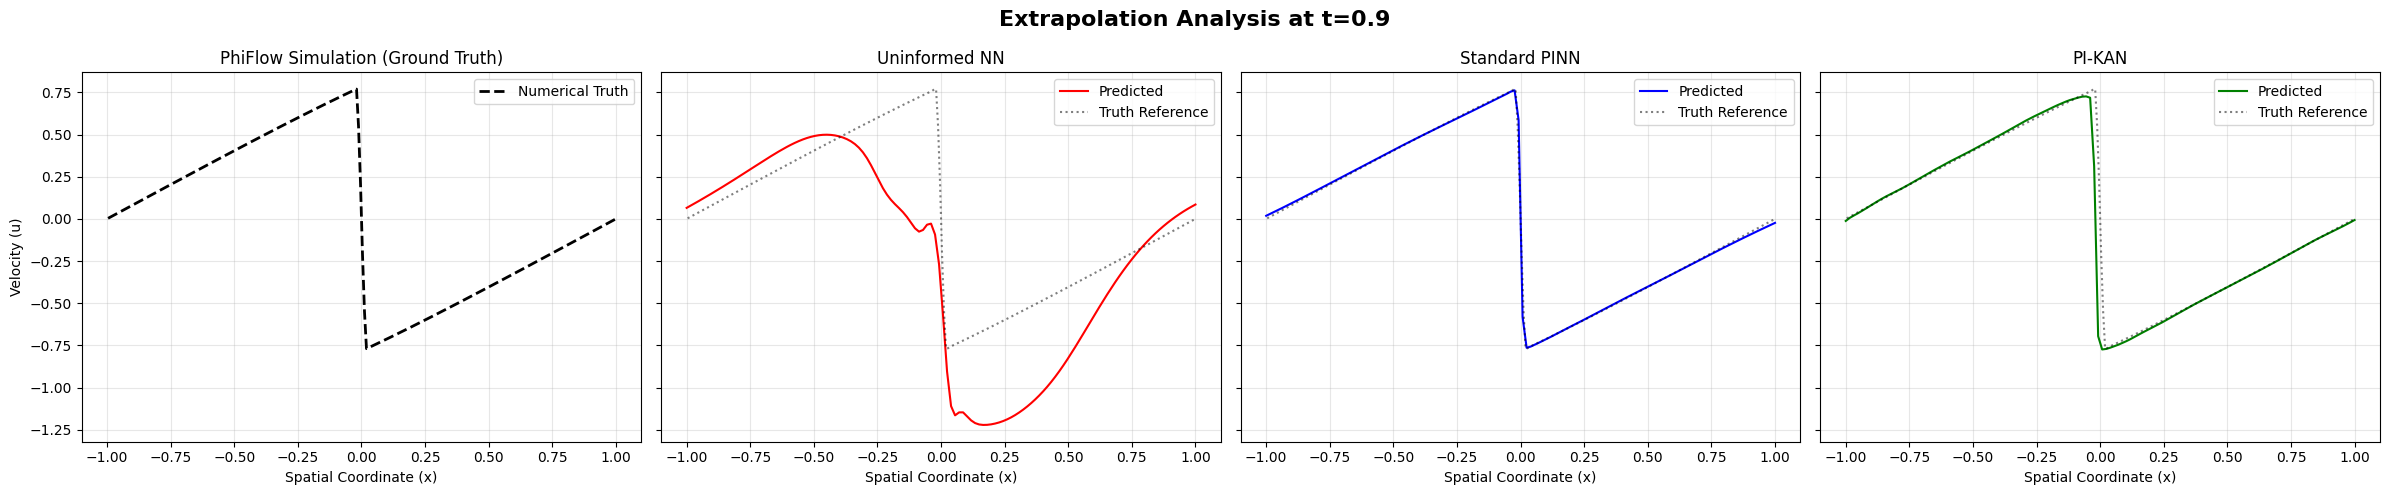

In [64]:
evaluate_models(model_pinn, model_uninformed, PIKAN, x_test, u_test, 128, t_eval=0.9)

In [ ]:
import matplotlib.gridspec as gridspec

def visualize_heatmaps(model_uninformed, model_pinn, model_pikan, x_flat, t_flat, u_exact_flat, extrapolation_horizon=0.8):
    
    # 1. Device Configuration and Evaluation Mode Activation
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    
    model_uninformed.eval()
    model_pinn.eval()
    model_pikan.eval()
    
    # 2. Spatiotemporal Grid Reconstruction
    # To utilize contour plotting, the flattened coordinate arrays must be reshaped 
    # back into their intrinsic 2D topological matrix.
    nx = len(np.unique(x_flat))
    nt = len(np.unique(t_flat))
    
    X_grid = x_flat.reshape(nt, nx)
    T_grid = t_flat.reshape(nt, nx)
    U_exact = u_exact_flat.reshape(nt, nx)
    
    # 3. Model Inference Execution
    with torch.no_grad():
        x_tensor = torch.tensor(x_flat, dtype=torch.float32).view(-1, 1).to(device)
        t_tensor = torch.tensor(t_flat, dtype=torch.float32).view(-1, 1).to(device)
        
        # Standard MLPs take separated spatial and temporal coordinate tensors
        u_pred_un = model_uninformed(x_tensor, t_tensor).cpu().numpy().reshape(nt, nx)
        u_pred_pinn = model_pinn(x_tensor, t_tensor).cpu().numpy().reshape(nt, nx)
        
        # The KAN architecture expects a concatenated spatiotemporal input vector
        kan_input = torch.cat([x_tensor, t_tensor], dim=1)
        u_pred_pikan = model_pikan(kan_input).cpu().numpy().reshape(nt, nx)

    # 4. Point-Wise Absolute Error Computation
    # This quantifies the deviation from the governing physical reality
    err_un = np.abs(U_exact - u_pred_un)
    err_pinn = np.abs(U_exact - u_pred_pinn)
    err_pikan = np.abs(U_exact - u_pred_pikan)
    
    # 5. Advanced Topographical Layout Formulation (GridSpec)
    fig = plt.figure(figsize=(24, 12))
    gs = gridspec.GridSpec(2, 12, figure=fig)
    fig.suptitle("Entire Domain Visualization", fontsize=20, fontweight='bold', y=0.98)
    
    cmap_fields = 'jet'
    cmap_errors = 'magma'
    levels = 100
    
    # =========================================================================
    # ROW 1: VELOCITY FIELDS (4 Plots, spanning 3 columns each)
    # =========================================================================
    ax_gt = fig.add_subplot(gs[0, 0:3])
    c_gt = ax_gt.contourf(X_grid, T_grid, U_exact, levels=levels, cmap=cmap_fields)
    ax_gt.set_title("Simulated Ground Truth", fontsize=14)
    ax_gt.set_ylabel("Time (t)", fontsize=12)
    fig.colorbar(c_gt, ax=ax_gt, fraction=0.046, pad=0.04)

    ax_pred_un = fig.add_subplot(gs[0, 3:6], sharex=ax_gt, sharey=ax_gt)
    c_un = ax_pred_un.contourf(X_grid, T_grid, u_pred_un, levels=levels, cmap=cmap_fields)
    ax_pred_un.set_title("Uninformed NN", fontsize=14)
    fig.colorbar(c_un, ax=ax_pred_un, fraction=0.046, pad=0.04)

    ax_pred_pinn = fig.add_subplot(gs[0, 6:9], sharex=ax_gt, sharey=ax_gt)
    c_pinn = ax_pred_pinn.contourf(X_grid, T_grid, u_pred_pinn, levels=levels, cmap=cmap_fields)
    ax_pred_pinn.set_title("Standard PINN", fontsize=14)
    fig.colorbar(c_pinn, ax=ax_pred_pinn, fraction=0.046, pad=0.04)

    ax_pred_pikan = fig.add_subplot(gs[0, 9:12], sharex=ax_gt, sharey=ax_gt)
    c_pikan = ax_pred_pikan.contourf(X_grid, T_grid, u_pred_pikan, levels=levels, cmap=cmap_fields)
    ax_pred_pikan.set_title("PI-KAN", fontsize=14)
    fig.colorbar(c_pikan, ax=ax_pred_pikan, fraction=0.046, pad=0.04)

    # =========================================================================
    # ROW 2: ABSOLUTE ERROR FIELDS (3 Plots, spanning 4 columns each)
    # =========================================================================
    ax_err_un = fig.add_subplot(gs[1, 0:4], sharex=ax_gt, sharey=ax_gt)
    c_err_un = ax_err_un.contourf(X_grid, T_grid, err_un, levels=levels, cmap=cmap_errors)
    ax_err_un.set_title("Uninformed Absolute Error", fontsize=14)
    ax_err_un.set_xlabel("Space (x)", fontsize=12)
    ax_err_un.set_ylabel("Time (t)", fontsize=12)
    fig.colorbar(c_err_un, ax=ax_err_un, fraction=0.046, pad=0.04)

    ax_err_pinn = fig.add_subplot(gs[1, 4:8], sharex=ax_gt, sharey=ax_gt)
    c_err_pinn = ax_err_pinn.contourf(X_grid, T_grid, err_pinn, levels=levels, cmap=cmap_errors)
    ax_err_pinn.set_title("PINN Absolute Error", fontsize=14)
    ax_err_pinn.set_xlabel("Space (x)", fontsize=12)
    fig.colorbar(c_err_pinn, ax=ax_err_pinn, fraction=0.046, pad=0.04)

    ax_err_pikan = fig.add_subplot(gs[1, 8:12], sharex=ax_gt, sharey=ax_gt)
    c_err_pikan = ax_err_pikan.contourf(X_grid, T_grid, err_pikan, levels=levels, cmap=cmap_errors)
    ax_err_pikan.set_title("PI-KAN Absolute Error", fontsize=14)
    ax_err_pikan.set_xlabel("Space (x)", fontsize=12)
    fig.colorbar(c_err_pikan, ax=ax_err_pikan, fraction=0.046, pad=0.04)

    # =========================================================================
    # Contextual Annotations (The Extrapolation Horizon)
    # =========================================================================
    axes = [ax_gt, ax_pred_un, ax_pred_pinn, ax_pred_pikan, ax_err_un, ax_err_pinn, ax_err_pikan]
    for ax in axes:
        ax.axhline(y=extrapolation_horizon, color='white', linestyle='--', linewidth=2, alpha=0.85)
        # Only add the text to the leftmost plots of each row to avoid visual clutter
        if ax in [ax_gt, ax_err_un]:
            ax.text(0.0, extrapolation_horizon + 0.02, 'Extrapolation Horizon t = 0.8', color='white', ha='center', fontsize=10, fontweight='bold')
            
    plt.tight_layout()
    # Adjust top padding to account for the super title
    plt.subplots_adjust(top=0.92) 
    plt.show()

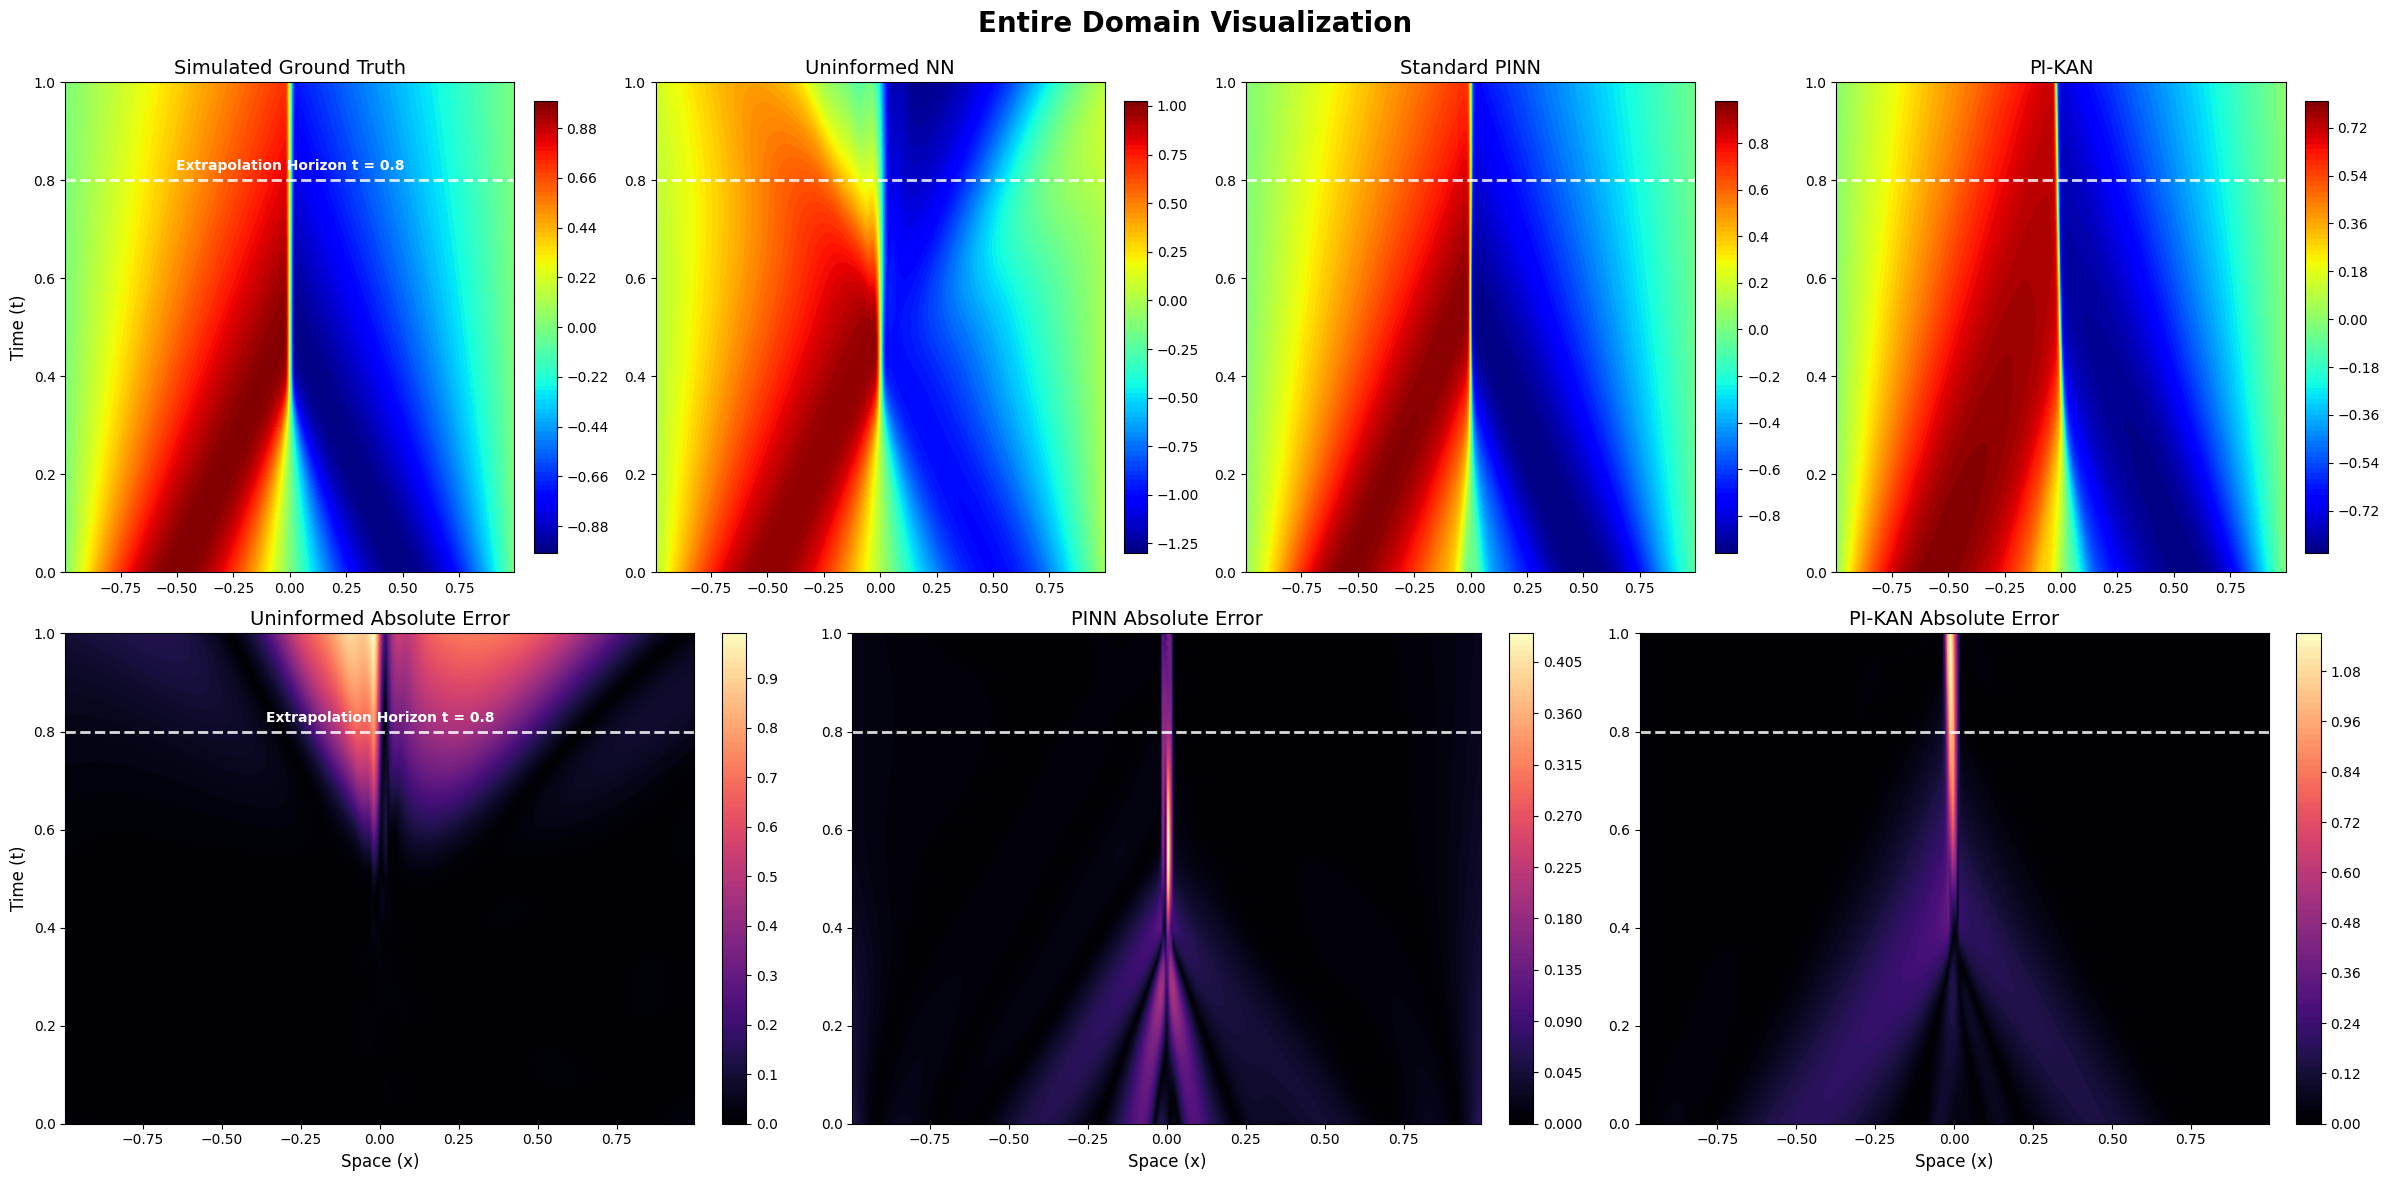

In [72]:
visualize_heatmaps(model_uninformed, model_pinn, PIKAN, burgers_simulation_data['x'], burgers_simulation_data['t'], burgers_simulation_data['u'])

In [73]:
model_pinn.count_params()

AttributeError: 'PINN' object has no attribute 'count_params'

In [80]:
pinn_params = sum(p.numel() for p in model_pinn.parameters() if p.requires_grad)
pinn_params

3441

In [81]:
kan_params = sum(p.numel() for p in PIKAN.parameters() if p.requires_grad)
kan_params

6440